In [ ]:
# try to use torch rewrite rbf-fd-poly
# import torch
# import scipy
# from scipy.io import loadmat
# import numpy as np
# import time
# import matplotlib.pyplot as plt
# np.random.seed(100)
# dtype = torch.float64
# device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# def relative_loss(predict, exact):
#     error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
#     return error

# # ===========================================================
# # RBF–Gaussian
# # ===========================================================
# def phi_gauss(eps, r): # rbf
#     return torch.exp(-(eps**2) * r**2)

# def laplace_phi_gauss(eps, r): # 2d Laplacian rbf derivative
#     return phi_gauss(eps, r) * (4 * eps**4 * r**2 - 4 * eps**2)

# # ===========================================================
# # Fill-distance
# # ===========================================================
# def fill_distance(X):
#     """
#     X: (N,2) torch tensor
#     """
#     N = X.shape[0]
#     h = torch.zeros(N, dtype=X.dtype, device=X.device)
#     for i in range(N):
#         others = torch.cat([X[:i], X[i+1:]], dim=0)
#         h[i] = torch.min(torch.norm(X[i] - others, dim=1))
#     return torch.max(h)

# # ===========================================================
# # Main RBF-FD solver (pure PyTorch)
# # ===========================================================
# def rbf_fd_poly_solve_poisson(X, Yin, Yb, f_func, g_func, reg, eps, K):
#     """
#     X:  (N,2) torch tensor, RBF source points
#     Yin: (M1,2) interior points
#     Yb:  (M2,2) boundary points
#     f_func, g_func: Python callable returning torch tensor
#     reg: regularization
#     eps: RBF shape parameter
#     K: number of neighbors
#     """
#     device = X.device
#     dtype = X.dtype

#     N = X.shape[0]
#     M1 = Yin.shape[0]
#     M2 = Yb.shape[0]
#     M = M1 + M2

#     # Combine evaluation points
#     Y = torch.cat([Yin, Yb], dim=0)

#     # Compute distance to all source points
#     dists = torch.cdist(Y, X)  # (M, N)

#     # Find K nearest neighbors
#     _, idx = torch.topk(-dists, K, dim=1)  # largest negative = smallest distance
#     dist_K = torch.gather(dists, 1, idx)   # (M, K)

#     # Construct dense L matrix
#     L = torch.zeros(M, N, dtype=dtype, device=device)
#     W_ide = torch.zeros((M, K+3), dtype=dtype, device=device)
#     W_lap = torch.zeros((M, K+3), dtype=dtype, device=device)
#     # Construct RHS
#     if callable(f_func):
#        RHS = torch.cat([f_func(Yin[:, 0], Yin[:, 1]),
#                      g_func(Yb[:,0], Yb[:, 1])], dim=0)
#     else:
#         f_func = f_func.to(device) # (M,1)
#         RHS = torch.cat([f_func[:M1,:],g_func(Yb[:,0:1], Yb[:,1:])], dim=0) # (M,1)
    
#     AP = torch.zeros(K+3,K+3,dtype=dtype,device=device)
#     P = torch.ones(K,3,dtype=dtype,device=device)
#     O = torch.zeros(3,3,dtype=dtype,device=device)
#     RHS_lap = torch.zeros(K+3,1, dtype=dtype, device=device)
#     RHS_ide = torch.ones(K+3,1, dtype=dtype, device=device)

#     for i in range(M):
#         AP.zero_()
#         RHS_lap.zero_()
#         RHS_ide.zero_()
#         P.zero_()

#         y = Y[i] # (2,)
#         idx_local = idx[i]               # (K,)
#         Z = X[idx_local]                 # (K,2)
#         diff = Z[:, None, :] - Z[None, :, :] # (K,K,2)
#         dist_ZZ = torch.norm(diff, dim=2)    # (K,K)
#         # Phi_jj = Phi(dist_ZZ) # (K,K)
#         Phi_jj = phi_gauss(eps, dist_ZZ)      # (K,K)

#         phi_xj = phi_gauss(eps, dist_K[i]).unsqueeze(-1) # (K,1)
#         lap_phi = laplace_phi_gauss(eps, dist_K[i]).unsqueeze(-1)  # (K,1)
#         ## W_ide
#         P[:,1:] = Z
#         P[:,0] = 1.0
#         AP[:K,:] = torch.cat([Phi_jj,P],dim=1) # (K,K+3)
#         AP[K:,:-3] = P.T # (3,K+3)
        
#         RHS_ide[:K,:] = phi_xj
#         RHS_ide[K:K+1,0:1] = 1.0
#         RHS_ide[K+1:,0:1] = y.view(-1,1)
#         w_ide = torch.linalg.solve(AP + 1e-12 * torch.eye(K+3).to(device),RHS_ide).T # (1,K+3)
#         W_ide[i:i+1,:] = w_ide
#         ## W_lap
#         # Laplace weights: laplace_phi = Phi_jj w_lap

#         RHS_lap[0:K,:] = lap_phi
#         w_lap = torch.linalg.solve(AP + 1e-12 * torch.eye(K+3).to(device),RHS_lap).T # (1,K+3)
#         W_lap[i:i+1,:] = w_lap

#         L[i, idx_local] = - w_lap[:,:K] if i < M1 else w_ide[:,:K]

#     # ===========================================================
#     # Solve linear system L U = RHS
#     # ===========================================================
#     if M == N:
#         UX = torch.linalg.solve(L, RHS) # (N,1)
#     else:
#         UX = torch.linalg.lstsq(L, RHS) 
#     # ===========================================================
#     # Evaluate solution at Y
#     # ===========================================================
#     UY = torch.zeros(M, dtype=dtype, device=device)
#     LL = torch.zeros(M, N, dtype=dtype, device=device)
#     for i in range(M):
#         idx_local = idx[i]
#         LL[i,idx_local] = LL[i,idx_local] + W_ide[i,:K]
#     UY = LL.matmul(UX)
#     return UY

# # ===========================================================

# data = loadmat('./data_poisson/mydata_sigma1_l0_25.mat')
# p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F_new'],data['U_new'],data['in'],data['bc']  # sigma = 1, l = 0.25
# index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python indexprint(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
# dtype = torch.float64
# p,f_0,u_0,f_new,u_new = torch.tensor(p, dtype=dtype, device=device), \
#                          torch.tensor(f_0, dtype=dtype, device=device).view(-1,1), \
#                          torch.tensor(u_0, dtype=dtype, device=device).view(-1,1), \
#                          torch.tensor(f_new[:,1:2], dtype=dtype, device=device), \
#                          torch.tensor(u_new[:,1:2], dtype=dtype, device=device)
# # ===========================================================
# import torch.nn as nn
# import torch.nn.functional as F
# torch.set_default_dtype(torch.float64)

# # ----------------------------
# K = 50            # stencil size
# reg = 1e-12   # local Tikhonov for Phi_jj
# h = fill_distance(p)
# rho = 2.5 * h
# eps = torch.sqrt(1.0 / rho)

# # ----------------------------
# # 构造测试点
# # ----------------------------
# Y = p
# Y.requires_grad = True
# M = Y.shape[0]
# N = p.shape[0]
# M2= index_bc.shape[0] # number of boundary points
# M1= M - M2

# # ----------------------------
# Yin = Y[index_in,:]
# Yb = Y[index_bc,:]
# Y = torch.cat([Yin,Yb],dim = 0)

# def g_func(x,y):
#     return 0 * x * y + 1
# # ----------------------------
# UY = rbf_fd_poly_solve_poisson(p, Yin, Yb, f_new, g_func, reg, eps, K)

# u_new = torch.cat([u_new[index_in,:],u_new[index_bc,:]],dim = 0)
# error_u = relative_loss(UY, u_new)
# print(f'Relative L2 error in u, compared with FEM: {error_u.item():.3e}')

# UY = UY.detach().cpu().numpy()
# u_new = u_new.cpu().numpy()
# Y = Y.detach().cpu().numpy()

# u_true = u_new


# error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
# # print(error)
# print(f'L infity error in u: {error.max().item():.3e}')
# error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
# print(f'Relative L2 error in u: {error_u.item():.3e}')

# plt.figure(figsize=(6,5))
# plt.scatter(Y[:,0], Y[:,1], c = np.abs(UY - u_true), cmap='viridis', s=10)
# plt.colorbar(label='U (numerical)')
# plt.title('RBF-FD solution')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.show()
 

# Compared with true referrence

内部 source 点数: 4504
边界点数: 100
patch 数: 49
evaluation 点数: 4504


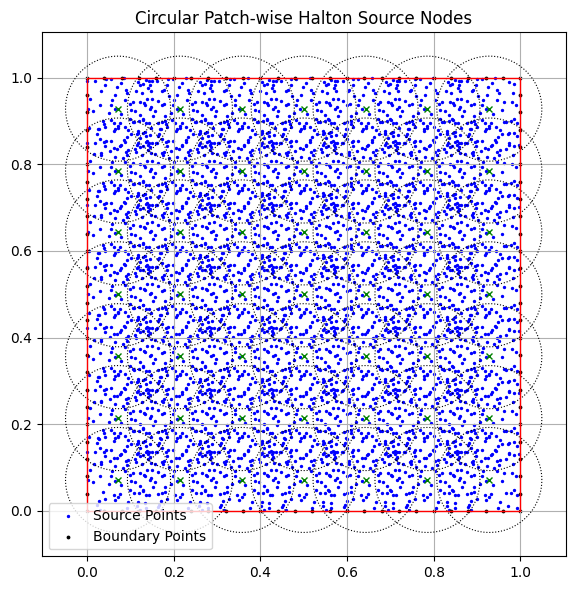

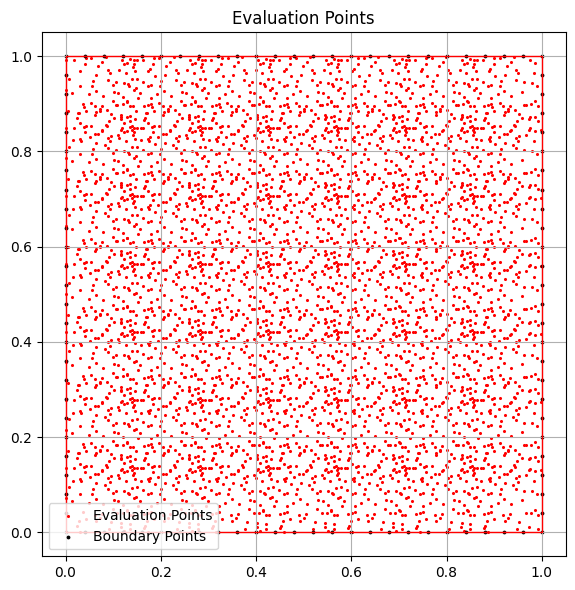

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. van der Corput
# =========================================================
def vandercorput(n, base):
    n = np.asarray(n, dtype=np.int64)
    out = np.zeros_like(n, dtype=np.float64)

    denom = base
    current = n.copy()

    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current //= base
        denom *= base

    return out


# =========================================================
# 2. Halton sequence
# =========================================================
def halton_sequence(N, dim):
    primes = [2, 3, 5, 7, 11, 13]
    H = np.zeros((N, dim))
    idx = np.arange(1, N + 1)

    for j in range(dim):
        H[:, j] = vandercorput(idx, primes[j])

    return H


def generator_points_square(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap=0.2,
    mode="c-rbf-pum"
):
    """
    Square domain (0,1)^2
    Circular patches + patch-wise Halton nodes
    """

    x_min, x_max = 0.0, 1.0
    y_min, y_max = 0.0, 1.0

    # =====================================================
    # patch centers
    # =====================================================
    H = (x_max - x_min) / N_patch_grid

    x_centers = np.linspace(
        x_min + H / 2,
        x_max - H / 2,
        N_patch_grid
    )
    y_centers = np.linspace(
        y_min + H / 2,
        y_max - H / 2,
        N_patch_grid
    )

    Xc, Yc = np.meshgrid(x_centers, y_centers)
    centers = np.column_stack([Xc.ravel(), Yc.ravel()])

    R_patch = (1 + overlap) * np.sqrt(2) * H / 2
    R_all = R_patch * np.ones(centers.shape[0])

    ptch = {
        "C": centers,
        "R": R_all
    }

    # =====================================================
    # reference Halton disc
    # =====================================================
    Hq = halton_sequence(N_local_per_patch, 2)

    theta = 2 * np.pi * Hq[:, 0]
    r = np.sqrt(Hq[:, 1]) * R_patch

    X_ref = np.column_stack([
        r * np.cos(theta),
        r * np.sin(theta)
    ])

    # =====================================================
    # patch-wise source nodes
    # =====================================================
    X_inner_list = []

    for c in centers:
        X_local = X_ref + c

        mask = (
            (X_local[:, 0] >= x_min) &
            (X_local[:, 0] <= x_max) &
            (X_local[:, 1] >= y_min) &
            (X_local[:, 1] <= y_max)
        )

        X_inner_list.append(X_local[mask])

    X_inner = np.vstack(X_inner_list)

    # =====================================================
    # evaluation points
    # =====================================================
    if mode == "c-rbf-pum":
        grid_eval = X_inner.copy()

    elif mode == "ls-rbf-pum":
        n_eval = int(np.sqrt(X_inner.shape[0]) * 2)
        xe = np.linspace(x_min, x_max, n_eval)
        ye = np.linspace(y_min, y_max, n_eval)
        Xe, Ye = np.meshgrid(xe, ye)
        grid_eval = np.column_stack([Xe.ravel(), Ye.ravel()])

    else:
        raise ValueError("Unknown mode")

    # =====================================================
    # boundary points
    # =====================================================
    n_side = N_boundary // 4
    rem = N_boundary % 4
    counts = [n_side] * 4
    for i in range(rem):
        counts[i] += 1

    xb = np.linspace(x_min, x_max, counts[0], endpoint=False)
    bottom = np.column_stack([xb, y_min * np.ones_like(xb)])

    yr = np.linspace(y_min, y_max, counts[1], endpoint=False)
    right = np.column_stack([x_max * np.ones_like(yr), yr])

    xt = np.linspace(x_max, x_min, counts[2], endpoint=False)
    top = np.column_stack([xt, y_max * np.ones_like(xt)])

    yl = np.linspace(y_max, y_min, counts[3], endpoint=False)
    left = np.column_stack([x_min * np.ones_like(yl), yl])

    X_boundary = np.vstack([bottom, right, top, left])

    boundary_curve = np.array([
        [0, 0],
        [1, 0],
        [1, 1],
        [0, 1],
        [0, 0]
    ])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve


# =========================================================
# 4. Plot
# =========================================================
def plot_generator_points(
    X_inner,
    X_boundary,
    ptch,
    grid_eval,
    boundary_curve
):
    C = ptch["C"]
    R = ptch["R"]
    theta = np.linspace(0, 2 * np.pi, 200)

    # =========================
    # Figure 1
    # =========================
    plt.figure(figsize=(7, 6))
    ax = plt.gca()

    for i in range(C.shape[0]):
        x = C[i, 0] + R[i] * np.cos(theta)
        y = C[i, 1] + R[i] * np.sin(theta)

        ax.plot(x, y, 'k:', linewidth=0.8)
        ax.plot(C[i, 0], C[i, 1], 'gx', markersize=5)

    ax.plot(boundary_curve[:, 0], boundary_curve[:, 1], 'r-', linewidth=1.0)

    ax.scatter(X_inner[:, 0], X_inner[:, 1],
               s=8, c='b', marker='.', label='Source Points')

    ax.scatter(X_boundary[:, 0], X_boundary[:, 1],
               s=12, c='k', marker='.', label='Boundary Points')

    ax.set_aspect('equal')
    ax.set_title('Circular Patch-wise Halton Source Nodes')
    ax.grid(True)
    ax.legend()
    plt.tight_layout()

    # =========================
    # Figure 2
    # =========================
    plt.figure(figsize=(7, 6))
    ax2 = plt.gca()

    ax2.plot(boundary_curve[:, 0], boundary_curve[:, 1], 'r-', linewidth=1.0)

    ax2.scatter(grid_eval[:, 0], grid_eval[:, 1],
                s=6, c='r', marker='.', label='Evaluation Points')

    ax2.scatter(X_boundary[:, 0], X_boundary[:, 1],
                s=12, c='k', marker='.', label='Boundary Points')

    ax2.set_aspect('equal')
    ax2.set_title('Evaluation Points')
    ax2.grid(True)
    ax2.legend()
    plt.tight_layout()

    plt.show()


# =========================================================
# 5. Main
# =========================================================
if __name__ == "__main__":
    N_patch_grid = 7
    N_local_per_patch = 100
    N_boundary = 100
    overlap = 0.2
    mode = "c-rbf-pum"

    X_inner, X_boundary, ptch, grid_eval, boundary_curve = \
        generator_points_square(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            mode
        )

    print("内部 source 点数:", X_inner.shape[0])
    print("边界点数:", X_boundary.shape[0])
    print("patch 数:", ptch["C"].shape[0])
    print("evaluation 点数:", grid_eval.shape[0])

    plot_generator_points(
        X_inner,
        X_boundary,
        ptch,
        grid_eval,
        boundary_curve
    )

In [4]:

import torch
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.spatial import cKDTree, distance
from scipy.linalg import cholesky
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, lsqr
import matplotlib.pyplot as plt

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = None)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = None)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = None) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
	
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    # nn.init.normal_(m.bias, mean=0.0, std=1)
                    m.bias.data.zero_()



def laplacian_phi_wrt_y(phi_net, y, X, eps=1e-8):
    """
    y: tensor (1,2) evalution points, requires_grad = True
    X: tensor (K,2) source points
    Returns: phi_vals (K,1), laplacian_y (K,1), grad_y (K,2)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    if y.dim()==1:
        y = y.unsqueeze(0)   # (1,2)
    K = X.shape[0]
    # compute r_j
    diff = y - X          # (K,2) if y (1,2)
    r = torch.norm(diff, dim=1, keepdim=True)   # (K,1)
    r = r.clamp(min=eps)  # 防止除零

    r.requires_grad_(True)    # 需要对 r 求导
    phi_vals = phi_net(r)     # (K,1)
    # phi_vals = phi_gauss(eps,r) # to check whether the laplace using autograd is correct

    # phi'(r)
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True,
    )[0]   # (K,1)

    # phi''(r)
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=True
    )[0]   # (K,1)

    n = y.shape[1]  # dimension, n = 2 here
    lap_r = d2phi_dr2 + (n-1)/r * dphi_dr   # (K,1),
    # print("relative error between  is",relative_loss(lap_r, laplace_phi_gauss(eps, r)))
    # 一阶向量梯度 wrt y： ∇_y φ = φ'(r) * (y - x)/r
    grad_y = dphi_dr * (diff / r)    # broadcasting (K,2): (grad_y1,grad_y2) 
    phi_vals = phi_vals.detach().cpu().numpy()
    lap_r = lap_r.detach().cpu().numpy()
    grad_y = grad_y.detach().cpu().numpy()
    return phi_vals, lap_r, grad_y

import time 
def rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0
    """
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M, N))
    W_ide = np.zeros((M, K))
    W_lap = np.zeros((M, K))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")
    start_time = time.time()
    for i in range(M):
        RHS_lap = np.zeros((K,1))
        RHS_ide = np.ones((K,1))
        A = np.zeros((K,K))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        # print(np.max(np.max(Phi_jj)), np.min(np.min(Phi_jj)))
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)
        ## RHS_lap, RHS_ide
        RHS_lap = lap_phi
        RHS_ide = phi_xj
        ## W_ide, W_lap
        A  =  Phi_jj  + reg * np.eye(K) # (K,K)
        w_ide = np.linalg.solve(A,RHS_ide).T # (1,K+3)
        W_ide[i:i+1,:] = w_ide
        w_lap = np.linalg.solve(A,RHS_lap).T # (1,K+Noder)
        W_lap[i:i+1,:] = w_lap
        L[i, idx_local] = - w_lap if i < M1 else w_ide
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    end_time = time.time()
    print("Compiling matrix cost",end_time - start_time,"seconds")
    L1 = L.tocsr()
    if M == N:
        UX = spsolve(L1, RHS)
    else:
        Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)

    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    LL = lil_matrix((M, N),dtype=np.float64)
    for i in range(M):
        idx_local = idx[i,:]    # (K,)
        LL[i,idx_local] = LL[i,idx_local] + W_ide[i,:]
    LL = LL.tocsr()
    UY = LL.dot(UX).reshape(-1,1)
    return UY,L,LL

def poly2D(Z, order):
    K = Z.shape[0]
    Norder = (order+1)*(order+2)//2
    P = np.zeros((K, Norder))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
            idx += 1
    return P

def poly2D_at_point(y, order):
    """Generate column vector of poly basis at single point y (2D)"""
    Norder = (order+1)*(order+2)//2
    p_y = np.zeros((Norder,1))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            p_y[idx,0] = (y[0]**i) * (y[1]**j)
            idx += 1
    return p_y

def laplacian_poly2D(order, y):
    """
    y: (2,) point
    return: column vector (Norder,1) of Laplacian evaluated at y
    """
    Norder = (order+1)*(order+2)//2
    lap = np.zeros((Norder,1))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            val = 0.0
            if i >= 2:
                val += i*(i-1)*y[0]**(i-2) * y[1]**j
            if j >= 2:
                val += j*(j-1)*y[0]**i * y[1]**(j-2)
            lap[idx,0] = val
            idx += 1
    return lap

def rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M, N))
    W_ide = np.zeros((M, K+Norder))
    W_lap = np.zeros((M, K+Norder))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")

    O = np.zeros((Norder,Norder))
    start_time = time.time()
    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)

        ## W_ide
        
        P = poly2D(Z, order)  # (K,Norder)
        AP[:K,:] = np.concatenate([Phi_jj,P], axis = 1) # (K,K+3)
        AP[K:,:-Norder] = P.T # (6,K)
        ## W_ide, RHS_ide
        
        p_y = poly2D_at_point(y, order)  # (Norder,1)
        RHS_ide[:K,0] = phi_xj[:,0]                           # shape (K,)
        RHS_ide[K:,0] = p_y[:,0]
        AP = AP + reg * np.eye(K+Norder)
        w_ide = np.linalg.solve(AP,RHS_ide).T # (1,K+3)
        W_ide[i:i+1,:] = w_ide
        ## W_lap
        # Laplace weights: laplace_phi = Phi_jj w_lap

        RHS_lap[:K,0] = lap_phi[:,0]
        RHS_lap[K:,0] = laplacian_poly2D(order, y)[:,0]
        w_lap = np.linalg.solve(AP,RHS_lap).T # (1,K+Noder)
        W_lap[i:i+1,:] = w_lap

        L[i, idx_local] = - w_lap[:,:K] if i < M1 else w_ide[:,:K]
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    end_time = time.time()
    print("Compiling matrix cost",end_time - start_time,"seconds")
    L1 = L.tocsr()
    cond_L = np.linalg.cond(L1.todense())
    print("cond(L) =", cond_L)



    if M == N:
        UX = spsolve(L1, RHS)
    else:
        UX = lsqr(L1, RHS)[0]

    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    LL = lil_matrix((M, N),dtype=np.float64)
    for i in range(M):
        idx_local = idx[i,:]    # (K,)
        LL[i,idx_local] = LL[i,idx_local] + W_ide[i,:K]
    LL = LL.tocsr()
    cond_LI = np.linalg.cond(LL.todense())
    print("cond(LI) =", cond_LI)
    UY = LL.dot(UX).reshape(-1,1)
    return UY,L,LL

# # ===========================================================
# # Evaluate solution at Y
# # ===========================================================
def test(L,LL,f_func,g_func,Yin,Yb):
    """
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, u_func: Python callable returning torch tensor
    idx: X in Y' kdtree
    """
    M,N = L.shape[0],L.shape[1]
    M1,M2 = Yin.shape[0],Yb.shape[0]
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")
    L1 = L.tocsr()
    if M == N:
        UX = spsolve(L1, RHS)
    else:
        Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)
    LL = LL.tocsr()
    UY = LL.dot(UX).reshape(-1,1)
    return UY

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

Compiling matrix cost 0.9574131965637207 seconds
cond(L) = 550302977.2108297
cond(LI) = 8229271.277495747
p = 1; L infity error in u_rfmfd: 1.645e-04
p = 1; Relative L2 error in u_rfmfd: 1.247e-04
Compiling matrix cost 0.9735050201416016 seconds
p = 0; L infity error in u_rfmfd: 9.175e-05
p = 0; Relative L2 error in u: 9.203e-05


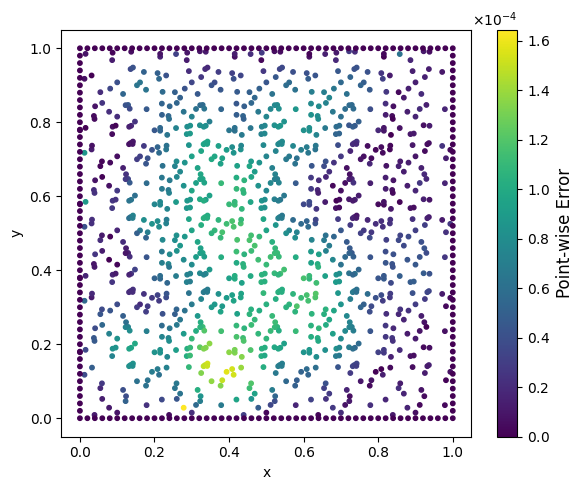

In [5]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double()
# #===========================================================
# data = loadmat('./data_poisson/mydata_sigma1_l0_25.mat')
# p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F_new'],data['U_new'],data['in'],data['bc']  # sigma = 1, l = 0.25
# index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# # print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
# X = p
# Y = X
# M = Y.shape[0]
# M2 = index_bc.shape[0]# 生成样本点已经给定
# M1 = M - M2
# # print(index_in.shape, index_bc.shape)
# K = 50
# testnum = 0
# Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
# f_func = f_new[index_in,testnum] 
# g_func = u_new[index_bc,testnum]
# order = 2
# reg = 1e-12
# u_true = u_new[:,testnum]
# u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)

# # ===========================================================
# u_func = lambda x, y: np.sin(x) * np.cos(y)
# f_func = lambda x, y: 2.0 * np.sin(x) * np.cos(y)
# g_func = lambda x, y: np.sin(x) * np.cos(y)

# u_func = lambda x, y: np.sin(x) * np.sin(y)
# f_func = lambda x, y: 2.0 * np.sin(x) * np.sin(y)
# g_func = lambda x, y: np.sin(x) * np.sin(y)

# u_func = lambda x, y: x * np.sin(y)
# f_func = lambda x, y: 0 * np.sin(y) + x * np.sin(y)
# g_func = lambda x, y: x * np.sin(y)

u_func = lambda x, y: x * np.cos(y)
f_func = lambda x, y: 0 * np.cos(y) +  x * np.cos(y)
g_func = lambda x, y: x * np.cos(y)


torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 50
N_boundary = 200
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, _, _ , _ = generator_points_square(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
K = 50
reg = 1e-12
order = 1
u_true = u_func(Y[:,0:1], Y[:,1:2])

# # ===========================================================


UY,L,LL = rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)
# print(u_true.shape,UY.shape)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
# print(error)
print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')

UY_p0,L,LL = rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg)
error = np.abs(UY_p0 - u_true)#/np.abs(u_true + 1e-6)

print(f'p = 0; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = np.linalg.norm(UY_p0 - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'p = 0; Relative L2 error in u: {error_u.item():.3e}')


import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig(f'p={order}_error_200.eps', bbox_inches='tight')
plt.show()


$Operator learning$

In [6]:

import torch
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.spatial import cKDTree, distance
from scipy.linalg import cholesky
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = None)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = None)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = None) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
	
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    # nn.init.normal_(m.bias, mean=0.0, std=1)
                    m.bias.data.zero_()




def laplacian_phi_wrt_y(phi_net, y, X, eps=1e-8):
    """
    y: tensor (1,2) evalution points, requires_grad = True
    X: tensor (K,2) source points
    Returns: phi_vals (K,1), laplacian_y (K,1), grad_y (K,2)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    if y.dim()==1:
        y = y.unsqueeze(0)   # (1,2)
    K = X.shape[0]
    # compute r_j
    diff = y - X          # (K,2) if y (1,2)
    r = torch.norm(diff, dim=1, keepdim=True)   # (K,1)
    r = r.clamp(min=eps)  # 防止除零

    r.requires_grad_(True)    # 需要对 r 求导
    phi_vals = phi_net(r)     # (K,1)
    # phi_vals = phi_gauss(eps,r) # to check whether the laplace using autograd is correct

    # phi'(r)
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True,
    )[0]   # (K,1)

    # phi''(r)
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=True
    )[0]   # (K,1)

    n = y.shape[1]  # dimension, n = 2 here
    lap_r = d2phi_dr2 + (n-1)/r * dphi_dr   # (K,1),
    # print("relative error between  is",relative_loss(lap_r, laplace_phi_gauss(eps, r)))
    # 一阶向量梯度 wrt y： ∇_y φ = φ'(r) * (y - x)/r
    grad_y = dphi_dr * (diff / r)    # broadcasting (K,2): (grad_y1,grad_y2) 
    phi_vals = phi_vals.detach().cpu().numpy()
    lap_r = lap_r.detach().cpu().numpy()
    grad_y = grad_y.detach().cpu().numpy()
    return phi_vals, lap_r, grad_y

def poly2D(Z, order):
    K = Z.shape[0]
    Norder = (order+1)*(order+2)//2
    P = np.zeros((K, Norder))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
            idx += 1
    return P

def poly2D_at_point(y, order):
    """Generate column vector of poly basis at single point y (2D)"""
    Norder = (order+1)*(order+2)//2
    p_y = np.zeros((Norder,1))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            p_y[idx,0] = (y[0]**i) * (y[1]**j)
            idx += 1
    return p_y

def laplacian_poly2D(order, y):
    """
    y: (2,) point
    return: column vector (Norder,1) of Laplacian evaluated at y
    """
    Norder = (order+1)*(order+2)//2
    lap = np.zeros((Norder,1))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            val = 0.0
            if i >= 2:
                val += i*(i-1)*y[0]**(i-2) * y[1]**j
            if j >= 2:
                val += j*(j-1)*y[0]**i * y[1]**(j-2)
            lap[idx,0] = val
            idx += 1
    return lap

def rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M, N))
    W_ide = np.zeros((M, K+Norder))
    W_lap = np.zeros((M, K+Norder))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")

    O = np.zeros((Norder,Norder))
    start_time = time.time()
    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)

        ## W_ide

        P = poly2D(Z, order)  # (K,Norder)
        AP[:K,:] = np.concatenate([Phi_jj,P], axis = 1) # (K,K+3)
        AP[K:,:-Norder] = P.T # (6,K)
        ## W_ide, RHS_ide

        p_y = poly2D_at_point(y, order)  # (Norder,1)
        RHS_ide[:K,0] = phi_xj[:,0]                           # shape (K,)
        RHS_ide[K:,0] = p_y[:,0]
        AP = AP + reg * np.eye(K+Norder)
        w_ide = np.linalg.solve(AP,RHS_ide).T # (1,K+3)
        W_ide[i:i+1,:] = w_ide
        ## W_lap
        # Laplace weights: laplace_phi = Phi_jj w_lap
        
        RHS_lap[:K,0] = lap_phi[:,0]
        RHS_lap[K:,0] = laplacian_poly2D(order, y)[:,0]
        w_lap = np.linalg.solve(AP,RHS_lap).T # (1,K+Noder)
        W_lap[i:i+1,:] = w_lap

        L[i, idx_local] = - w_lap[:,:K] if i < M1 else w_ide[:,:K]
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    end_time = time.time()
    print("Compiling matrix cost",end_time - start_time,"seconds")
    L1 = L.tocsr()
    if M == N:
        UX = spsolve(L1, RHS)
    else:
        Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)

    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    LL = lil_matrix((M, N),dtype=np.float64)
    for i in range(M):
        idx_local = idx[i,:]    # (K,)
        LL[i,idx_local] = LL[i,idx_local] + W_ide[i,:K]
    LL = LL.tocsr()
    UY = LL.dot(UX).reshape(-1,1)
    return UY,L,LL

# # ===========================================================
# # Evaluate solution at Y
# # ===========================================================
def test_solver(L, LL, RHS):
    """
    L  : (M,N) sparse operator matrix
    LL : (M,N) sparse interpolation matrix
    RHS: (M,Q) numpy array

    Returns
    -------
    UY : (M,Q) numpy array
    """
    L = L.tocsr()
    LL = LL.tocsr()

    M, N = L.shape
    Q = RHS.shape[1]
    # -------------------------
    # Solve L UX = RHS
    # -------------------------
    if M == N:
        # spsolve supports multiple RHS
        UX = spsolve(L, RHS)          # (N,Q)
    else:
        # least squares: solve column by column
        Q, R = np.linalg.qr(L.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)
    # -------------------------
    # Evaluate at Y
    # -------------------------
    UY = LL @ UX                      # (M,Q)
    return UY

def rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0
    """
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    L = lil_matrix((M, N))
    W_ide = np.zeros((M, K))
    W_lap = np.zeros((M, K))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        RHS[:M1,:] = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        RHS[-M2:,0:1] = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        RHS[-M2:,:] = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")

    for i in range(M):
        RHS_lap = np.zeros((K,1))
        RHS_ide = np.ones((K,1))
        A = np.zeros((K,K))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)
        ## RHS_lap, RHS_ide
        RHS_lap = lap_phi
        RHS_ide = phi_xj
        ## W_ide, W_lap
        A  =  Phi_jj  + reg * np.eye(K) # (K,K)
        w_ide = np.linalg.solve(A,RHS_ide).T # (1,K+3)
        W_ide[i:i+1,:] = w_ide
        w_lap = np.linalg.solve(A,RHS_lap).T # (1,K+Noder)
        W_lap[i:i+1,:] = w_lap
        L[i, idx_local] = - w_lap if i < M1 else w_ide
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    L1 = L.tocsr()
    if M == N:
        UX = spsolve(L1, RHS)
    else:
        Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        UX = np.linalg.solve(R, Q.T @ RHS)

    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    LL = lil_matrix((M, N),dtype=np.float64)
    for i in range(M):
        idx_local = idx[i,:]    # (K,)
        LL[i,idx_local] = LL[i,idx_local] + W_ide[i,:]
    LL = LL.tocsr()
    UY = LL.dot(UX).reshape(-1,1)
    return UY,L,LL


def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

Compiling matrix cost 0.5549986362457275 seconds
(697, 1)
FD L nnz = 34850
FD LL nnz = 34850
0.044808114768231544
L infity error in u: 6.012e-02
Relative L2 error in u: 1.939e-02


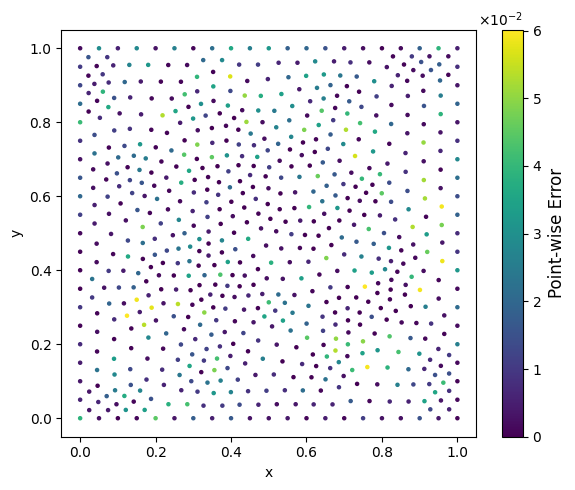

In [7]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# #===========================================================
# u_func = lambda x, y: np.sin(x) * np.cos(y)
# f_func = lambda x, y: 2.0 * np.sin(x) * np.cos(y)
# g_func = lambda x, y: np.sin(x) * np.cos(y)

# u_func = lambda x, y: np.sin(x) * np.sin(y)
# f_func = lambda x, y: 2.0 * np.sin(x) * np.sin(y)
# g_func = lambda x, y: np.sin(x) * np.sin(y)

# u_func = lambda x, y: x * np.sin(y)
# f_func = lambda x, y: 0 * np.sin(y) + x * np.sin(y)
# g_func = lambda x, y: x * np.sin(y)

# u_func = lambda x, y: x * np.cos(y)
# f_func = lambda x, y: 0 * np.cos(y) + x * np.cos(y)
# g_func = lambda x, y: x * np.cos(y)
# #===========================================================
# #==================== Evaluate points Y ====================
# #===========================================================
data = loadmat('./data_poisson/mydata_100_pdetool_square_697.mat') # sigma = 1, l = 0.25
# data = loadmat('./data_poisson/mydata_100_pdetool_square_10201.mat') # sigma = 1, l = 0.25
p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F'],data['U'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2
# # print(index_in.shape, index_bc.shape)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,testnum] 
g_func = u_new[index_bc,testnum]
order = 1
K = 50
reg = 1e-12
u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
X = p
# N_patch_grid = 5
# N_local_per_patch = 200
# N_boundary = 200
# R_ptch = 0.8
# mode = "c-rbf-pum"
# # generate points
# X_inner, X_boundary, _, _ , _ = generator_points_star(
# N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
# X = np.vstack([X_inner, X_boundary])|

# # ===========================================================
if order == 0:
    UY,L,LL = rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg)
else:
    UY,L,LL = rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)

# UY,L,LL = rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)
print(u_true.shape)
print("FD L nnz =", L.nnz)
print("FD LL nnz =", LL.nnz)

error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
print(error[index_bc].max().item())
print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig(f'./result/p={order}_error_200_size{M}.eps', bbox_inches='tight')
plt.show()


(697, 100) (617, 100) (80, 100)
p = 1, inference time: 0.0237 秒


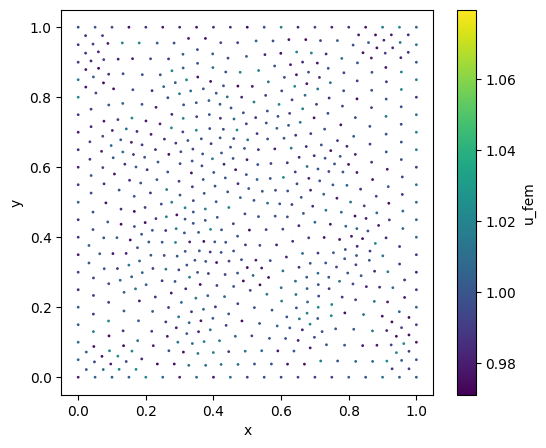

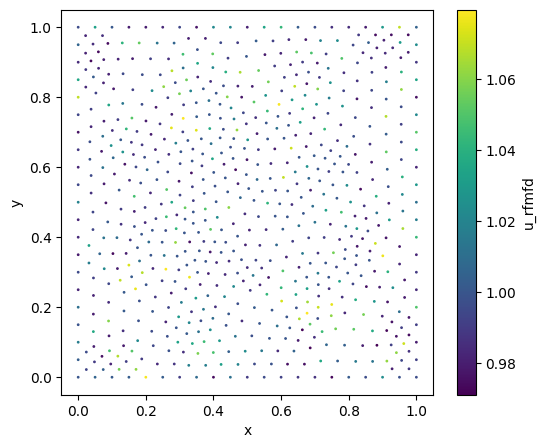

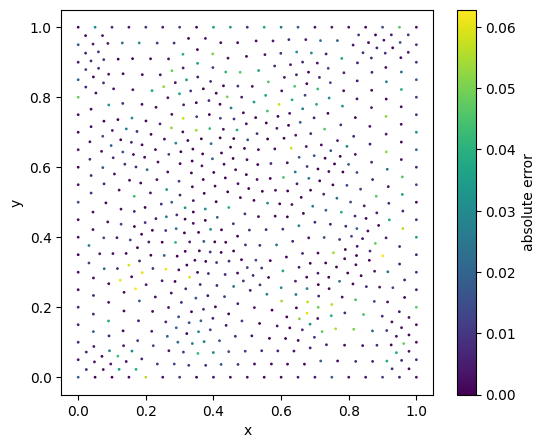

p = 1, test on 100 samples. The mean of max error: 3.027694e-02, and mean of relative L2 error: 1.029344e-02
p = 1, test on 100 samples. The variance of max error: 2.307450e-04, and variance of relative L2 error: 2.374261e-05


In [36]:
import time
E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_vec = f_new[index_in,:] 
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)
RHS = np.concatenate([f_vec,g_vec],axis = 0 )

start_time = time.time()
UY = test_solver(L, LL, RHS)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

np.random.seed(100)
q = np.random.randint(0,100)

import matplotlib.colors as mcolors

v_min = min(u_true[:, q].min(), UY[:, q].min())
v_max = max(u_true[:, q].max(), UY[:, q].max())
norm = mcolors.Normalize(vmin=v_min, vmax=v_max)
plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true[:,q], cmap='viridis', s=1, norm=norm)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/p={order}_u_fem_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY[:,q] , cmap='viridis', s=1, norm=norm)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/p={order}_u_frmfd_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = error_inf[:,q], cmap='viridis', s=1)
plt.colorbar(label='absolute error')
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

(10201, 1)
0.0003938414646458277
L infity error in u: 5.180e-04
Relative L2 error in u: 1.609e-04


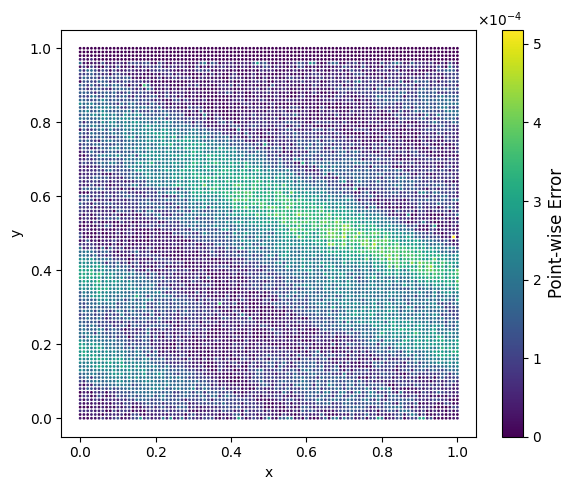

(10201, 100) (9801, 100) (400, 100)
p = 2, inference time: 4.8009 秒


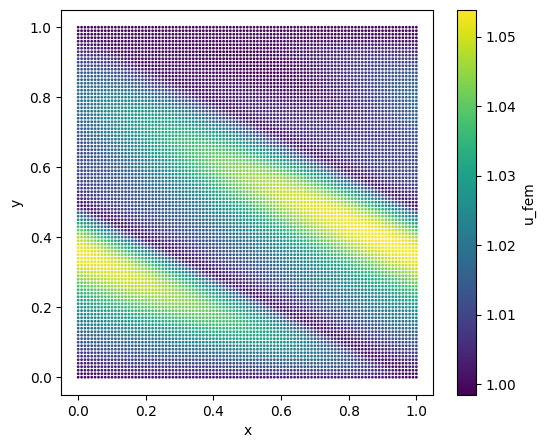

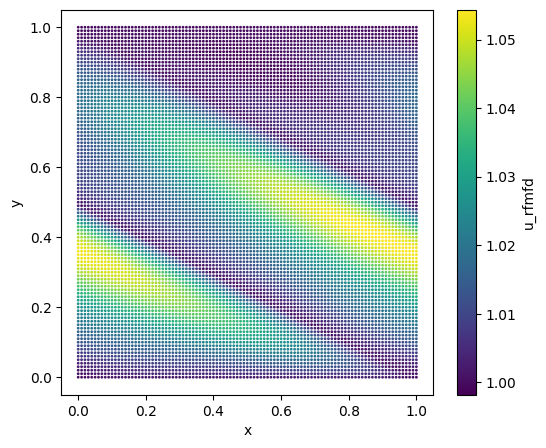

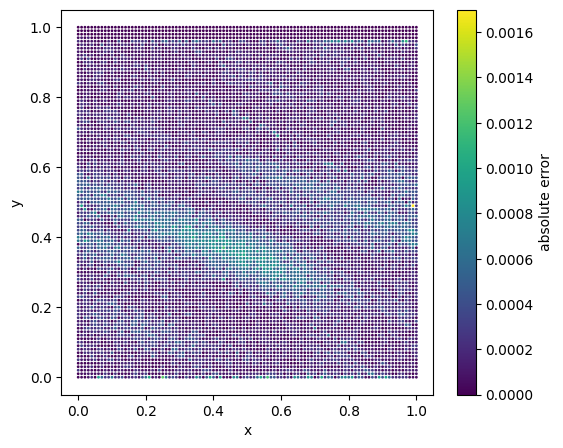

p = 2, test on 100 samples. The mean of max error: 2.143063e-03, and mean of relative L2 error: 3.816577e-04
p = 2, test on 100 samples. The variance of max error: 1.444889e-06, and variance of relative L2 error: 4.140081e-08


In [33]:

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# #===========================================================
# u_func = lambda x, y: np.sin(x) * np.cos(y)
# f_func = lambda x, y: 2.0 * np.sin(x) * np.cos(y)
# g_func = lambda x, y: np.sin(x) * np.cos(y)

# u_func = lambda x, y: np.sin(x) * np.sin(y)
# f_func = lambda x, y: 2.0 * np.sin(x) * np.sin(y)
# g_func = lambda x, y: np.sin(x) * np.sin(y)

# u_func = lambda x, y: x * np.sin(y)
# f_func = lambda x, y: 0 * np.sin(y) + x * np.sin(y)
# g_func = lambda x, y: x * np.sin(y)

# u_func = lambda x, y: x * np.cos(y)
# f_func = lambda x, y: 0 * np.cos(y) + x * np.cos(y)
# g_func = lambda x, y: x * np.cos(y)
# #===========================================================
# #==================== Evaluate points Y ====================
# #===========================================================
# data = loadmat('./data_poisson/mydata_100_pdetool_square_697.mat')
data = loadmat('./data_poisson/mydata_100_pdetool_square_10201.mat') # sigma = 1, l = 0.25
p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F'],data['U'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2
# # print(index_in.shape, index_bc.shape)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,testnum] 
g_func = u_new[index_bc,testnum]
order = 2
K = 100
reg = 1e-13
u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
X = p
# N_patch_grid = 5
# N_local_per_patch = 200
# N_boundary = 200
# R_ptch = 0.8
# mode = "c-rbf-pum"
# # generate points
# X_inner, X_boundary, _, _ , _ = generator_points_star(
# N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
# X = np.vstack([X_inner, X_boundary])|

# # ===========================================================
if order == 0:
    UY,L,LL = rfm_fd_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg)
else:
    UY,L,LL = rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)


# UY,L,LL = rfm_fd_poly_solve_poisson_nn(X, Yin, Yb, f_func, g_func, Phi, K, reg, order)


print(u_true.shape)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
print(error[index_bc].max().item())
print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=1)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig(f'./result/p={order}_error_xcos_operator.eps', bbox_inches='tight')
plt.show()

import time
E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_vec = f_new[index_in,:] 
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)
RHS = np.concatenate([f_vec,g_vec],axis = 0 )

start_time = time.time()
UY = test_solver(L, LL, RHS)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

np.random.seed(100)
q = np.random.randint(0, 100)

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true[:,q], cmap='viridis', s=1)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/p={order}_u_fem_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY[:,q] , cmap='viridis', s=1)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/p={order}_u_frmfd_size{M}.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = error_inf[:,q], cmap='viridis', s=1)
plt.colorbar(label='absolute error')
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/p={order}_error_size{M}.eps', bbox_inches='tight')
plt.show()

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")





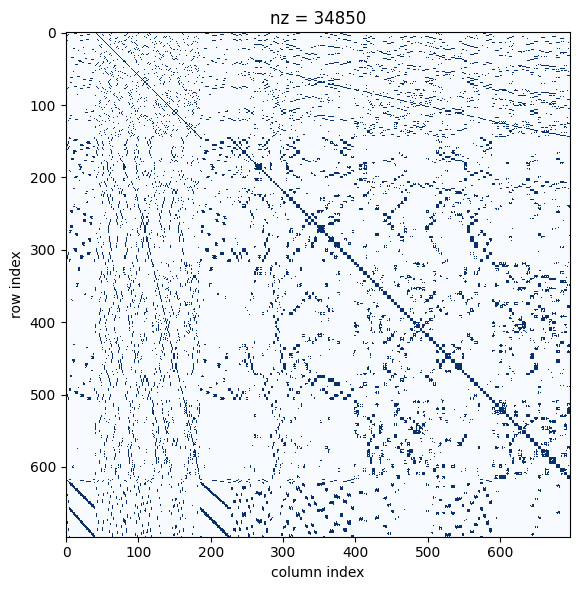

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(L)

In [15]:
for name, param in Phi.named_parameters():
    print(name, param.data)

input_layer.weight tensor([[ 0.2842],
        [-0.2967],
        [-0.1604],
        [-0.2334],
        [-0.5244],
        [-0.0046],
        [-0.2725],
        [ 0.2287],
        [-0.2161],
        [-0.0757],
        [-0.0685],
        [ 0.0640],
        [ 0.3066],
        [ 0.3625],
        [-0.0834],
        [ 0.0658],
        [ 0.3209],
        [-0.0518],
        [-0.1160],
        [-0.0907],
        [ 0.1197],
        [ 0.0820],
        [-0.0369],
        [ 0.0720],
        [ 0.0468],
        [-0.0157],
        [-0.4444],
        [ 0.1845],
        [-0.0036],
        [ 0.0795],
        [-0.2547],
        [ 0.3697],
        [-0.0387],
        [-0.0531],
        [ 0.0157],
        [-0.1510],
        [ 0.3340],
        [-0.0718],
        [ 0.1586],
        [-0.2193],
        [ 0.1426],
        [-0.0696],
        [ 0.3045],
        [ 0.1889],
        [-0.2389],
        [ 0.2154],
        [-0.2263],
        [-0.0997],
        [ 0.0391],
        [-0.2642]], device='cuda:1', dtype=torch.f